# Azure Image Generator Comparison

Compare **Azure GPT Image Generator** and **Azure MAI Generator** side by side using the same prompt.

## 1. Setup & Imports

In [1]:
import time
import sys
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


# Resolve the repo root so paths work no matter where Jupyter is launched from.
ROOT = find_repo_root(Path.cwd())
DATA_DIR = ROOT / "data"

# Add the src/ layout to sys.path so the generator package can be imported
# without needing an editable install.
sys.path.insert(0, str(ROOT / "src"))

from genai_image_compare.gpt_image_generator import AzureGPTImageGenerator
from genai_image_compare.mai_generator import AzureMAIGenerator

## 2. Load Environment Variables

In [2]:
import os

from dotenv import load_dotenv

load_dotenv()

gpt_endpoint = os.getenv("GPT_IMAGE_ENDPOINT")
mai_endpoint = os.getenv("MAI_ENDPOINT")
scope = os.getenv("AZURE_AUTH_SCOPE", "https://cognitiveservices.azure.com/.default")
width = os.getenv("AZURE_IMAGE_WIDTH", "1024")
height = os.getenv("AZURE_IMAGE_HEIGHT", "1024")
n = int(os.getenv("AZURE_IMAGE_N", "1"))
mai_model = os.getenv("MAI_MODEL", "MAI-Image-2.5")

assert gpt_endpoint, "GPT_IMAGE_ENDPOINT is not set in .env"
assert mai_endpoint, "MAI_ENDPOINT is not set in .env"

print(f"GPT endpoint : {gpt_endpoint}")
print(f"MAI endpoint : {mai_endpoint}")
print(f"Image size   : {width}x{height}")

GPT endpoint : https://ai-kpalepu2534ai084844026455.cognitiveservices.azure.com/openai/deployments/{model_name}/images/generations?api-version=2024-02-01
MAI endpoint : https://kp-azure-ai.services.ai.azure.com/mai/v1/images/generations?api-version=preview
Image size   : 1024x1024


## 3. Initialize Both Image Generators

In [3]:
client_dict = {}
for gpt_model in ["gpt-image-1-mini", "gpt-image-1.5", "gpt-image-2"]:
    gpt_client = AzureGPTImageGenerator(
        endpoint=gpt_endpoint,
        scope=scope,
        model=gpt_model,
        size=f"{width}x{height}",
        quality="low",
        output_compression=100,
        output_format="png",
        n=n,
    )
    client_dict[gpt_model] = gpt_client
for mai_model in ["MAI-Image-2.5", "MAI-Image-2.5-Flash", "MAI-Image-2e"]:
    mai_client = AzureMAIGenerator(
        endpoint=mai_endpoint,
        scope=scope,
        model=mai_model,
        width=int(width),
        height=int(height),
        n=n,
    )
    client_dict[mai_model] = mai_client

print("All generators initialized.")

All generators initialized.


## 4. Generate Images

In [4]:
prompts_df = pd.read_csv(DATA_DIR / "prompts" / "prompts.csv")
OUTPUT_PATH = DATA_DIR / "images"
TIMING_CSV = DATA_DIR / "results" / "timing_results.csv"

time_df = pd.read_csv(TIMING_CSV) if TIMING_CSV.exists() else pd.DataFrame()

In [5]:
from concurrent.futures import ThreadPoolExecutor

time_list = []


def generate_for_model(model_name, client, prompt_id, prompt):
    """Generate an image for a single model and measure how long it takes."""
    start_time = time.time()
    # if image already exists, skip generation and return time from time_df
    image_path = OUTPUT_PATH / model_name / f"{prompt_id}.png"
    if image_path.exists():
        existing_time = time_df[
            (time_df["ID"] == prompt_id) & (time_df["Model"] == model_name)
        ]["Time Taken (s)"]
        if not existing_time.empty:
            return model_name, image_path.read_bytes(), existing_time.values[0]
    image_bytes = client.generate(prompt)
    end_time = time.time()
    return model_name, image_bytes, end_time - start_time


for idx, row in tqdm(
    prompts_df.iterrows(), total=prompts_df.shape[0], desc="Processing prompts"
):
    prompt_id = row["ID"]
    prompt_cat = row["Category"]
    prompt = row["Prompt"]

    # Run all models in parallel for this prompt (calls are I/O-bound API requests)
    with ThreadPoolExecutor(max_workers=len(client_dict)) as executor:
        futures = [
            executor.submit(generate_for_model, model_name, client, prompt_id, prompt)
            for model_name, client in client_dict.items()
        ]
        for future in futures:
            model_name, image_bytes, elapsed = future.result()
            time_list.append(
                {
                    "ID": prompt_id,
                    "Category": prompt_cat,
                    "Prompt": prompt,
                    "Model": model_name,
                    "Time Taken (s)": elapsed,
                }
            )
            image_path = OUTPUT_PATH / model_name / f"{prompt_id}.png"
            image_path.parent.mkdir(parents=True, exist_ok=True)
            image_path.write_bytes(image_bytes)

Processing prompts:   0%|          | 0/12 [00:00<?, ?it/s]

[MAI-Image-2e] Token expires in 67.9 min[MAI-Image-2.5-Flash] Token expires in 67.9 min

[MAI-Image-2.5] Token expires in 67.9 min
[gpt-image-2] Token expires in 67.9 min
[MAI-Image-2e] Token expires in 67.5 min[MAI-Image-2.5] Token expires in 67.5 min

[gpt-image-2] Token expires in 67.5 min
[MAI-Image-2.5-Flash] Token expires in 67.5 min
[gpt-image-1.5] Token expires in 67.5 min
[gpt-image-1-mini] Token expires in 67.5 min
[gpt-image-2] Token expires in 66.5 min[gpt-image-1.5] Token expires in 66.5 min

[gpt-image-1-mini] Token expires in 66.5 min
[MAI-Image-2.5-Flash] Token expires in 66.5 min
[MAI-Image-2e] Token expires in 66.5 min
[MAI-Image-2.5] Token expires in 66.5 min
[gpt-image-1.5] Token expires in 65.8 min
[MAI-Image-2.5] Token expires in 65.8 min
[MAI-Image-2.5-Flash] Token expires in 65.8 min
[gpt-image-1-mini] Token expires in 65.8 min
[gpt-image-2] Token expires in 65.8 min
[MAI-Image-2e] Token expires in 65.8 min
[MAI-Image-2.5-Flash] Token expires in 65.3 min
[MAI-Im

In [6]:
time_df = pd.DataFrame(time_list)
TIMING_CSV.parent.mkdir(parents=True, exist_ok=True)
time_df.to_csv(TIMING_CSV, index=False)

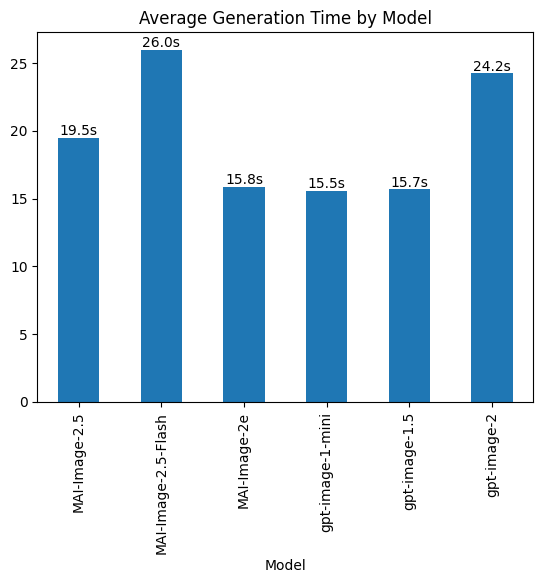

In [7]:
time_df.groupby("Model")["Time Taken (s)"].mean().plot(
    kind="bar", title="Average Generation Time by Model"
)
# add labels on top of bars
for index, value in enumerate(time_df.groupby("Model")["Time Taken (s)"].mean()):
    plt.text(index, value, f"{value:.1f}s", ha="center", va="bottom")